## Evaluation of the model performance: Confusion matrix 
The confusion matrix provides a detailed view of the model predictions.

It shows:
- correctly detected nominal windows (`True Negatives`),
- false alarms (`False Positives`),
- missed anomalies (`False Negatives`),
- and correctly detected anomalous windows (`True Positives`).

In telemetry anomaly detection, both false alarms and missed anomalies are important:
- excessive false alarms can overwhelm operators,
- while missed anomalies may hide critical system behaviors.

The confusion matrix helps us better understand these trade-offs before analyzing the classification metrics.

Ma trận nhầm lẫn cung cấp một cái nhìn chi tiết về dự đoán của mô hình.

Nó hiển thị:

- Cửa sổ bình thường được phát hiện chính xác (True Negatives)
- Cảnh báo sai (False Positives)
- Bất thường bị bỏ sót (False Negatives)
- Cửa sổ bất thường được phát hiện chính xác (True Positives)

Trong phát hiện bất thường trên dữ liệu telemetry, cả cảnh báo sai và bất thường bị bỏ sót đều quan trọng:

- Cảnh báo sai quá nhiều có thể làm quá tải các nhà điều hành
- Bất thường bị bỏ sót có thể che giấu các hành vi quan trọng của hệ thống

Ma trận nhầm lẫn giúp chúng ta hiểu rõ hơn các sự đánh đổi này trước khi phân tích các chỉ số đánh giá phân loại (classification metrics).

In [1]:
# B1.0 Let's import some dependencies first

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import os
import ast
from sklearn.preprocessing import StandardScaler
import pickle


In [2]:
# B1.1 Read labeled_anomalies.csv

path = "./data"
df = pd.read_csv(path+'/data/labeled_anomalies.csv')
df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


We can now inspect how many telemetry channels are available for each spacecraft mission in the dataset.

The dataset includes channels from:
- `SMAP` (Soil Moisture Active Passive)
- `MSL` (Mars Science Laboratory)

This provides a quick overview of the dataset composition before exploring the telemetry signals in detail.

Bây giờ chúng ta có thể kiểm tra số lượng kênh đo từ xa có sẵn cho từng nhiệm vụ tàu vũ trụ trong bộ dữ liệu.

Bộ dữ liệu bao gồm các kênh từ:

- SMAP (Soil Moisture Active Passive)
- MSL (Mars Science Laboratory)

Điều này cung cấp một cái nhìn tổng quan nhanh về thành phần của bộ dữ liệu trước khi chúng ta đi sâu khám phá các tín hiệu đo từ xa chi tiết hơn.

In [3]:
# B1.2 Check number of channels per mission

print("Number of SMAP channels: ",df[df['spacecraft']== 'SMAP'].count().chan_id)
print("Number of MSL channels: ",df[df['spacecraft']== 'MSL'].count().chan_id)

Number of SMAP channels:  55
Number of MSL channels:  27


For this tutorial, we will focus only on the `SMAP` telemetry channels.

The following code filters the dataframe to keep only the channels associated with the SMAP spacecraft mission.

Trong hướng dẫn này, chúng ta sẽ chỉ tập trung vào các kênh đo từ xa của SMAP.

Đoạn mã sau sẽ lọc dataframe để chỉ giữ lại các kênh liên quan đến nhiệm vụ tàu vũ trụ SMAP.

In [4]:
# B1.3 We take just SMAP channels

df_smap = df[df['spacecraft']== 'SMAP']
df_smap.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


We can now explore a specific telemetry channel in more detail.

The variable `c_name` can be changed to any available channel (e.g., `A-1`, `P-1`, `E-2`, etc.) to inspect different telemetry signals in the dataset.

In this example, we select the channel `T-1` and retrieve its corresponding metadata, including:
- anomaly intervals,
- anomaly classes,
- and the total number of samples in the channel.

Bây giờ chúng ta có thể khám phá chi tiết một kênh đo từ xa cụ thể.

Biến c_name có thể được thay đổi thành bất kỳ kênh nào có sẵn (ví dụ: A-1, P-1, E-2, v.v.) để kiểm tra các tín hiệu đo từ xa khác nhau trong bộ dữ liệu.

Trong ví dụ này, chúng ta chọn kênh T-1 và lấy metadata tương ứng, bao gồm:

- khoảng thời gian bất thường (anomaly intervals)
- loại bất thường (anomaly classes)
- tổng số mẫu dữ liệu trong kênh (total number of samples)

In [5]:
# B1.4 Exploring an specific channel: info

c_name = "T-1"
idx = df_smap.loc[df['chan_id']== c_name ].index

c_info = df_smap.iloc[idx]
c_info

,chan_id,spacecraft,anomaly_sequences,class,num_values
33,T-1,SMAP,"[[2399, 3898], [6550, 6585]]","[point, contextual]",8612


Next, we load the telemetry signal associated with the selected channel.

The anomaly intervals stored in `anomaly_sequences` are converted from string format into a Python list, allowing us to work directly with the anomaly start and end indices.

We then load the corresponding time series from the `test/` folder and inspect its shape.

Tiếp theo, chúng ta sẽ tải tín hiệu đo từ xa liên quan đến kênh đã chọn.

Các khoảng thời gian bất thường được lưu trong anomaly_sequences sẽ được chuyển từ dạng chuỗi (string) sang danh sách Python, cho phép chúng ta làm việc trực tiếp với chỉ số bắt đầu và kết thúc của bất thường.

Sau đó, chúng ta tải chuỗi thời gian (time series) tương ứng từ thư mục test/ và kiểm tra kích thước của dữ liệu.

In [6]:
# B1.5 Exploring an specific channel: size

anom_array = ast.literal_eval(c_info['anomaly_sequences'].values[0])

c_signal = np.load(f'{path}/data/test/{c_name}.npy')
print(f"Shape of time-series: {c_signal.shape}")

Shape of time-series: (8612, 25)


Shape: `(N, 25)`

- `N`: number of time samples in the telemetry channel.
- `25` variables corresponding to telemetry measurements and `S/R` (send/receive) command-related signals associated with the 12 spacecraft modules.

Kích thước dữ liệu (Shape): (N, 25)

- N: số lượng mẫu thời gian (time samples) trong kênh đo từ xa.
- 25 biến: tương ứng với các phép đo telemetry và các tín hiệu liên quan đến lệnh gửi/nhận (send/receive – S/R), liên quan đến 12 module của tàu vũ trụ.

We now visualize the telemetry signal corresponding to the first variable of the selected channel.

The red shaded regions indicate the anomaly intervals provided in `labelled_anomalies.csv`.

This allows us to observe how anomalous behaviors appear in the time series and highlights an important challenge in telemetry anomaly detection: anomalies can have very different durations, amplitudes, and temporal patterns.

Bây giờ chúng ta sẽ trực quan hóa tín hiệu đo từ xa tương ứng với biến đầu tiên của kênh đã chọn.

Các vùng màu đỏ thể hiện các khoảng thời gian bất thường được cung cấp trong labelled_anomalies.csv.

Điều này giúp chúng ta quan sát cách các hành vi bất thường xuất hiện trong chuỗi thời gian, đồng thời làm nổi bật một thách thức quan trọng trong phát hiện bất thường trên dữ liệu telemetry: các bất thường có thể có độ dài, biên độ và mẫu thời gian rất khác nhau.

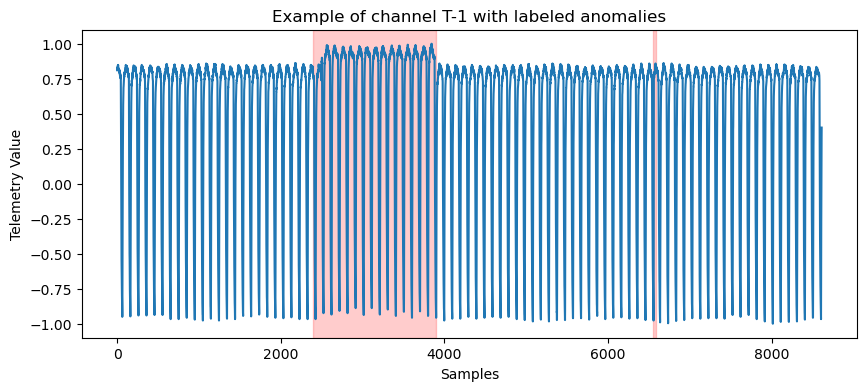

In [7]:
# B1.6 Exploring an specific channel: telemetry values and anomalies

telemetry_values = c_signal[:,0]

fig,ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(telemetry_values)
for anom in anom_array:
    ax.axvspan(anom[0], anom[1], color='red', alpha=0.2)
ax.set_xlabel('Samples')
ax.set_ylabel('Telemetry Value')
ax.set_title(f'Example of channel {c_name} with labeled anomalies')
plt.show()

------------

# Supervised Anomaly Detection

In supervised anomaly detection, machine learning models are trained using labeled examples of both nominal and anomalous behavior.
The objective is to learn decision boundaries that allow the model to distinguish between normal and anomalous patterns in unseen data.

In this section, we will:
- preprocess telemetry signals using sliding windows,
- generate window-level labels from anomaly intervals,
- extract features from each window,
- and train supervised classifiers to detect anomalous telemetry behavior.

This approach allows us to evaluate anomaly detection as a classification problem using labeled telemetry windows.

For this case we will use the original `test/` set, since it contains both nominal and anomalous telemetry behavior.

---------

Phát hiện bất thường có giám sát (Supervised Anomaly Detection)

Trong phát hiện bất thường có giám sát, các mô hình học máy được huấn luyện sử dụng các ví dụ đã được gán nhãn về cả hành vi bình thường và bất thường. Mục tiêu là học các ranh giới quyết định cho phép mô hình phân biệt giữa các mẫu bình thường và bất thường trên dữ liệu chưa thấy.

Trong phần này, chúng ta sẽ:

- Tiền xử lý tín hiệu đo từ xa (telemetry signals) bằng cửa sổ trượt (sliding windows)
- Tạo nhãn cho từng cửa sổ từ các khoảng thời gian bất thường
- Trích xuất đặc trưng (features) từ mỗi cửa sổ
- Huấn luyện các bộ phân loại có giám sát để phát hiện hành vi bất thường trong telemetry

Cách tiếp cận này cho phép chúng ta đánh giá phát hiện bất thường như một bài toán phân loại, sử dụng các cửa sổ telemetry đã được gán nhãn.

Trong trường hợp này, chúng ta sẽ sử dụng tập test/ gốc, vì nó chứa cả hành vi bình thường và bất thường trong dữ liệu đo từ xa.

## Step 2: Process the data to feed the ML model

### 2.1 Window-based preprocessing

Machine learning models usually require input samples with a fixed size. However, telemetry channels are long time series, often containing thousands of samples.

For example, a single SMAP channel may contain more than 7000 time samples. Instead of using the entire time series as one input sample, we divide it into smaller fixed-length segments called **windows**.

This allows us to transform a long telemetry signal into a dataset of multiple samples that can be used to train and evaluate machine learning models.

The windowing process is controlled by two main parameters:

- `window_size`: number of consecutive time samples included in each window.
- `stride`: number of samples used to move the window forward.

A smaller stride produces more overlapping windows, while a larger stride reduces the number of windows and the computational cost.

For the selected telemetry channel, we will apply sliding-window preprocessing to divide the time series into fixed-size windows.

Each window will contain `window_size` consecutive samples, and the starting point of each window will be separated by `stride` samples.

## Bước 2: Xử lý dữ liệu để đưa vào mô hình ML
### 2.1 Tiền xử lý dựa trên cửa sổ (Window-based preprocessing)

Các mô hình học máy thường yêu cầu các mẫu đầu vào có kích thước cố định. Tuy nhiên, các kênh đo từ xa (telemetry channels) là chuỗi thời gian dài, thường chứa hàng nghìn mẫu.

Ví dụ, một kênh SMAP duy nhất có thể chứa hơn 7000 mẫu thời gian. Thay vì sử dụng toàn bộ chuỗi thời gian làm một mẫu đầu vào duy nhất, chúng ta chia nó thành các đoạn nhỏ có độ dài cố định gọi là cửa sổ (windows).

Điều này cho phép chúng ta biến một tín hiệu telemetry dài thành một tập dữ liệu gồm nhiều mẫu, có thể dùng để huấn luyện và đánh giá các mô hình học máy.

Quá trình tạo cửa sổ được điều khiển bởi hai tham số chính:

- window_size: số lượng mẫu thời gian liên tiếp có trong mỗi cửa sổ.
- stride: số lượng mẫu dùng để di chuyển cửa sổ về phía trước.
Stride nhỏ → tạo ra nhiều cửa sổ chồng lấp nhau hơn.
Stride lớn → giảm số lượng cửa sổ và giảm chi phí tính toán.

Đối với kênh đo từ xa đã chọn, chúng ta sẽ áp dụng tiền xử lý bằng cửa sổ trượt để chia chuỗi thời gian thành các cửa sổ có kích thước cố định.

Mỗi cửa sổ sẽ chứa window_size mẫu liên tiếp.
Điểm bắt đầu của mỗi cửa sổ sẽ cách nhau stride mẫu.

In [8]:
# B2.0 Window based preprocessing for a single telemetry channel

window_size = 50
stride = 5

windows = []

for start in range(0, len(telemetry_values) - window_size + 1, stride):
    end = start + window_size
    window = telemetry_values[start:end]
    windows.append(window)

windows = np.array(windows)

print("Original signal shape:", telemetry_values.shape)
print("Windowed dataset shape:", windows.shape)

Original signal shape: (8612,)
Windowed dataset shape: (1713, 50)


If the original signal contains $N$ samples, the total number of generated windows is:

$\text{num\_windows} =\left\lfloor\frac{N - \text{window\_size}}{\text{stride}}\right\rfloor + 1$

After preprocessing, the original time series with shape $(N,)$ is transformed into a windowed dataset with shape $(\text{num\_windows}, \text{window\_size})$ where each row corresponds to one input sample for the machine learning model.

Nếu tín hiệu gốc chứa $N$ mẫu, tổng số cửa sổ được tạo ra là:

$\text{num\_windows} =\left\lfloor\frac{N - \text{window\_size}}{\text{stride}}\right\rfloor + 1$

Sau khi tiền xử lý, chuỗi thời gian gốc với kích thước $(N,)$ sẽ được biến đổi thành tập dữ liệu dạng cửa sổ với kích thước $(\text{num_windows}, \text{window_size})$, trong đó mỗi hàng tương ứng với một mẫu đầu vào cho mô hình học máy.

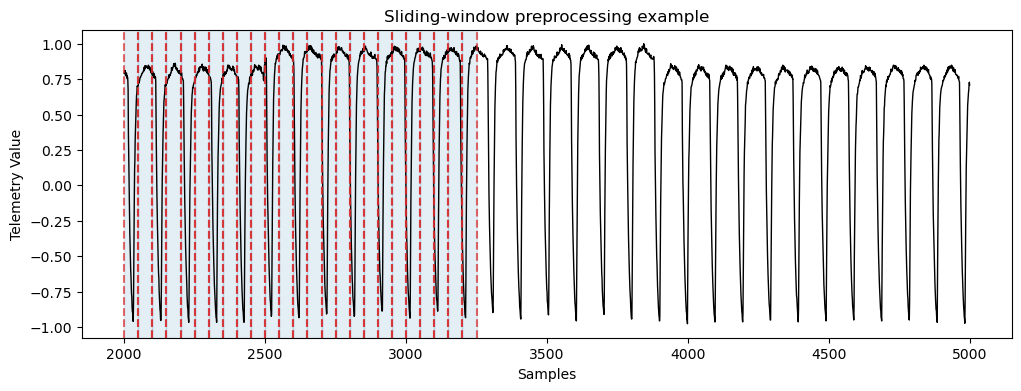

In [9]:
# B2.1 Visualize the obtained windows for a single telemetry channel

window_size = 50
stride = 50

# Show just a portion of the telemetry channel
start_plot = 2000
end_plot = 5000

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
    np.arange(start_plot, end_plot),
    telemetry_values[start_plot:end_plot],
    color='black',
    lw=1
)

# Show a number of windows inside the region
n_show = 25

for i in range(n_show):

    start = start_plot + i * stride
    end = start + window_size

    ax.axvspan(start, end, color='tab:blue', alpha=0.12)

    ax.axvline(start, color='tab:red', linestyle='--', alpha=0.7)
    ax.axvline(end, color='tab:red', linestyle='--', alpha=0.7)

ax.set_xlabel("Samples")
ax.set_ylabel("Telemetry Value")
ax.set_title("Sliding-window preprocessing example")

plt.show()

Since telemetry channels contain thousands of samples, we visualize only a small section of the signal to better illustrate the sliding-window process.

Try changing the values of `window_size` and `stride` to observe how the number of generated windows changes.

Vì các kênh đo từ xa chứa hàng nghìn mẫu, chúng ta sẽ chỉ trực quan hóa một đoạn nhỏ của tín hiệu để minh họa rõ hơn quá trình tạo cửa sổ trượt (sliding-window process).

Hãy thử thay đổi giá trị của window_size và stride để quan sát số lượng cửa sổ được tạo ra thay đổi như thế nào.

#### Things to consider for window-based processing:

1. `window_size`: How much temporal context should each sample contain?
   
Small windows:
  * More local information
  * Faster processing
  * May miss long anomalies

Large windows:
  * More temporal context
  * Better for long-duration events
  * Higher computational cost

2. `stride`: How much should the window move between consecutive samples?

Small stride:
  * More overlap
  * More training samples
  * Smoother temporal coverage

Large stride:
  * Fewer samples
  * Lower computational cost
  * Possible information loss
  
#### Những điều cần cân nhắc khi xử lý dữ liệu dựa trên cửa sổ:
1. window_size: Mỗi mẫu nên chứa bao nhiêu ngữ cảnh thời gian (temporal context)?

Cửa sổ nhỏ:
* Thông tin cục bộ nhiều hơn
* Xử lý nhanh hơn
* Có thể bỏ lỡ các bất thường dài

Cửa sổ lớn:
* Ngữ cảnh thời gian nhiều hơn
* Tốt hơn cho các sự kiện kéo dài
* Chi phí tính toán cao hơn
2. stride: Cửa sổ nên di chuyển bao nhiêu mẫu giữa các cửa sổ liên tiếp?

Stride nhỏ:
* Nhiều chồng lấp hơn
* Nhiều mẫu huấn luyện hơn
* Phủ sóng thời gian mượt hơn

Stride lớn:
* Ít mẫu hơn
* Chi phí tính toán thấp hơn
* Có thể mất thông tin


### 2.2 Window labeling

The original labels are defined per sample or anomaly interval but ML models operate on windows.

Original labels: anomaly from sample 2399 to 3898

But after windowing: each window needs ONE label

How should we label a window that contains both nominal and anomalous samples?
- Any anomalous sample = anomalous window
- Anomaly percentage threshold
- Majority voting

### 2.2 Gán nhãn cho cửa sổ (Window labeling)

Các nhãn gốc được xác định theo từng mẫu hoặc theo khoảng thời gian bất thường, nhưng các mô hình học máy hoạt động trên các cửa sổ.

Nhãn gốc: bất thường từ mẫu 2399 đến 3898

Nhưng sau khi chia cửa sổ: mỗi cửa sổ cần MỘT nhãn duy nhất

Vậy cách nào để gán nhãn cho một cửa sổ chứa cả mẫu bình thường và mẫu bất thường?

- Bất kỳ mẫu bất thường nào = cửa sổ bất thường
- Ngưỡng phần trăm bất thường: chỉ gán nhãn bất thường nếu phần trăm mẫu bất thường trong cửa sổ vượt ngưỡng nhất định
- Bỏ phiếu đa số (Majority voting): nhãn của cửa sổ dựa trên loại chiếm đa số trong các mẫu

In [10]:
# B2.2 See the resulting dataset and label size after window-processing

window_size = 200
stride = 200

# Sample-based labels: 0 = nominal, 1 = anomalous
sample_labels = np.zeros(len(telemetry_values), dtype=int)

for start, end in anom_array:
    sample_labels[start:end] = 1

# Window-based labeling
windows = []
window_labels = []
window_ranges = []

for start in range(0, len(telemetry_values) - window_size + 1, stride):
    end = start + window_size

    #If there is a single anomaly inside the window, the whole window is labelled as anomalous
    window = telemetry_values[start:end]
    label = 1 if sample_labels[start:end].sum() > 0 else 0

    windows.append(window)
    window_labels.append(label)
    window_ranges.append((start, end))

windows = np.array(windows)
window_labels = np.array(window_labels)
window_ranges = np.array(window_ranges)

print("Original signal shape:", telemetry_values.shape)
print("Windowed dataset shape:", windows.shape)
print("Window labels shape:", window_labels.shape)
print("Number of nominal windows:", np.sum(window_labels == 0))
print("Number of anomalous windows:", np.sum(window_labels == 1))

Original signal shape: (8612,)
Windowed dataset shape: (43, 200)
Window labels shape: (43,)
Number of nominal windows: 33
Number of anomalous windows: 10


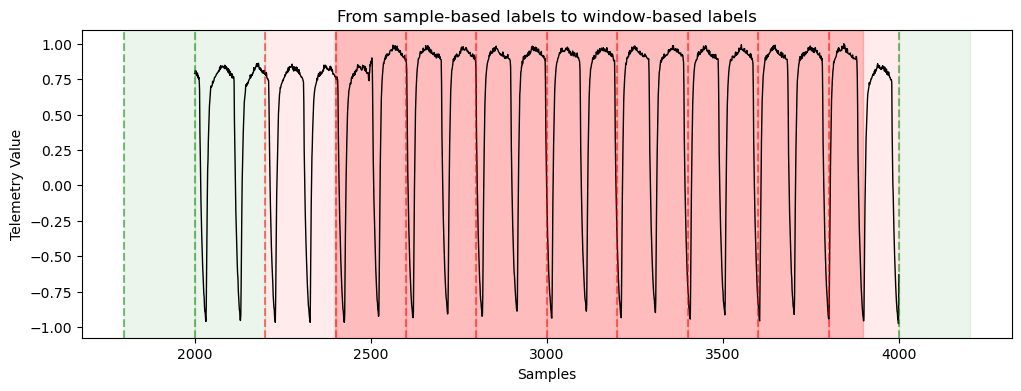

In [11]:
# B2.3 Comparison between the sample-based labels vs window-based labels

start_plot = 2000
end_plot = 4000

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    np.arange(start_plot, end_plot),
    telemetry_values[start_plot:end_plot],
    color='black',
    lw=1
)

# Sample-level anomaly regions
for anom_start, anom_end in anom_array:
    if anom_end >= start_plot and anom_start <= end_plot:
        ax.axvspan(
            max(anom_start, start_plot),
            min(anom_end, end_plot),
            color='red',
            alpha=0.2,
            label='Sample-level anomaly'
        )

# Window-level labels
for (w_start, w_end), label in zip(window_ranges, window_labels):
    if w_end >= start_plot and w_start <= end_plot:
        color = 'red' if label == 1 else 'green'
        ax.axvspan(w_start, w_end, color=color, alpha=0.08)
        ax.axvline(w_start, color=color, linestyle='--', alpha=0.5)

ax.set_xlabel("Samples")
ax.set_ylabel("Telemetry Value")
ax.set_title("From sample-based labels to window-based labels")

plt.show()

### 2.3 Preprocess the whole dataset

So far, we explored a single telemetry channel to better understand the structure of the data and the windowing process.

We now extend this preprocessing pipeline to all available SMAP channels.

The steps of this process are:
1. Load every telemetry channel
2. Apply sliding-window preprocessing
3. Generate window-level labels
4. Combine all windows into a single dataset matrix suitable for machine learning.

After preprocessing, the dataset will contain one row per window and one label per window indicating nominal or anomalous behavior.

This transforms the original collection of long telemetry time series into a structured dataset that can be directly used for supervised anomaly detection.

### 2.3 Tiền xử lý toàn bộ bộ dữ liệu

Cho đến nay, chúng ta đã khám phá một kênh đo từ xa duy nhất để hiểu rõ cấu trúc dữ liệu và quá trình tạo cửa sổ.

Bây giờ, chúng ta sẽ mở rộng pipeline tiền xử lý này cho tất cả các kênh SMAP có sẵn.

Các bước của quá trình này gồm:

1. Tải từng kênh đo từ xa
2. Áp dụng tiền xử lý bằng cửa sổ trượt (sliding-window preprocessing)
3. Tạo nhãn cho từng cửa sổ (window-level labels)
4. Kết hợp tất cả các cửa sổ thành một ma trận dữ liệu duy nhất, phù hợp để đưa vào mô hình học máy.

Sau khi tiền xử lý, tập dữ liệu sẽ có một hàng cho mỗi cửa sổ và một nhãn cho mỗi cửa sổ, thể hiện hành vi bình thường hoặc bất thường.

Điều này biến tập hợp các chuỗi thời gian dài ban đầu thành một tập dữ liệu có cấu trúc, có thể sử dụng trực tiếp cho phát hiện bất thường có giám sát (supervised anomaly detection).

In [12]:
# B 2.4 Helper functions to load and process the dataset
class NASASupervisedLoader:

    def __init__(
        self,
        root_dir,
        spacecraft="SMAP",
        window_size=50,
        stride=5,
        normalize=True
    ):

        self.root_dir = root_dir
        self.spacecraft = spacecraft
        self.window_size = window_size
        self.stride = stride
        self.normalize = normalize

        self.test_dir = os.path.join(
            root_dir+"/data",
            "test"
        )

        self.labels_df = pd.read_csv(
            os.path.join(
                root_dir,
                "./data/labeled_anomalies.csv"
            )
        )

        self.labels_df = self.labels_df[
            self.labels_df["spacecraft"] == spacecraft
        ]

    def load_channel(self, channel_id):

        path = os.path.join(
            self.test_dir,
            f"{channel_id}.npy"
        )

        data = np.load(path)

        if self.normalize:
            scaler = StandardScaler()
            data = scaler.fit_transform(data)[:,0]

        row = self.labels_df[
            self.labels_df["chan_id"] == channel_id
        ].iloc[0]

        anomaly_sequences = ast.literal_eval(
            row["anomaly_sequences"]
        )

        labels = np.zeros(len(data))

        for start, end in anomaly_sequences:
            labels[start:end+1] = 1

        return data, labels

    def create_windows(self, data, labels):

        X = []
        y = []

        for i in range(
            0,
            len(data) - self.window_size,
            self.stride
        ):

            window = data[
                i:i+self.window_size
            ]

            label_window = labels[
                i:i+self.window_size
            ]

            # ventana anómala si contiene
            # al menos una anomalía
            label = int(np.any(label_window))

            X.append(window)
            y.append(label)

        return np.array(X), np.array(y)

    def load_all(self):

        X_all = []
        y_all = []

        channels = self.labels_df["chan_id"].values

        for channel_id in channels:

            print(f"Loading {channel_id}")

            data, labels = self.load_channel(
                channel_id
            )

            X, y = self.create_windows(
                data,
                labels
            )

            X_all.append(X)
            y_all.append(y)

        X_all = np.concatenate(X_all, axis=0)
        y_all = np.concatenate(y_all, axis=0)

        return X_all, y_all

In [13]:
# B 2.5 Load and preprocess the whole dataset
loader = NASASupervisedLoader(
    root_dir="./data",
    spacecraft="SMAP",
    window_size=50,
    stride=5
)

X, y = loader.load_all()

print(f'Shape of dataset: {X.shape}')
print(f'Shape of labels:{y.shape}')

print("Nominal:", np.sum(y == 0))
print("Anomaly:", np.sum(y == 1))

Loading P-1
Loading S-1
Loading E-1
Loading E-2
Loading E-3
Loading E-4
Loading E-5
Loading E-6
Loading E-7
Loading E-8
Loading E-9
Loading E-10
Loading E-11
Loading E-12
Loading E-13
Loading A-1
Loading D-1
Loading P-2
Loading P-3
Loading D-2
Loading D-3
Loading D-4
Loading A-2
Loading A-3
Loading A-4
Loading G-1
Loading G-2
Loading D-5
Loading D-6
Loading D-7
Loading F-1
Loading P-4
Loading G-3
Loading T-1
Loading T-2
Loading D-8
Loading D-9
Loading F-2
Loading G-4
Loading T-3
Loading D-11
Loading D-12
Loading B-1
Loading G-6
Loading G-7
Loading P-7
Loading R-1
Loading A-5
Loading A-6
Loading A-7
Loading D-13
Loading P-2
Loading A-8
Loading A-9
Loading F-3
Shape of dataset: (88276, 50)
Shape of labels:(88276,)
Nominal: 76274
Anomaly: 12002


### 2.4 Train-test split

Once all telemetry windows have been generated and combined into a single dataset, we divide the data into training and testing subsets.

The training set is used to learn the patterns associated with nominal and anomalous telemetry behavior, while the test set is used to evaluate the model performance on unseen windows.

This separation is essential to assess how well the model generalizes to new telemetry data.

### 2.4 Chia tập huấn luyện – kiểm tra (Train-test split)

Khi tất cả các cửa sổ telemetry đã được tạo và kết hợp thành một tập dữ liệu duy nhất, chúng ta sẽ chia dữ liệu thành các tập huấn luyện và kiểm tra.

Tập huấn luyện (training set): dùng để học các mẫu hành vi bình thường và bất thường trong dữ liệu telemetry.
Tập kiểm tra (test set): dùng để đánh giá hiệu suất mô hình trên các cửa sổ chưa thấy trước đó.

Việc chia tách dữ liệu này là rất quan trọng để đánh giá khả năng tổng quát hóa của mô hình đối với dữ liệu telemetry mới.

In [14]:
# B2.6 Divide the data into training and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Nominal windows in training set:", np.sum(y_train == 0))
print("Anomalous windows in training set:", np.sum(y_train == 1))

print("Nominal windows in test set::", np.sum(y_test == 0))
print("Anomaly windows in test set::", np.sum(y_test == 1))

Nominal windows in training set: 61019
Anomalous windows in training set: 9601
Nominal windows in test set:: 15255
Anomaly windows in test set:: 2401


Model loaded successfully


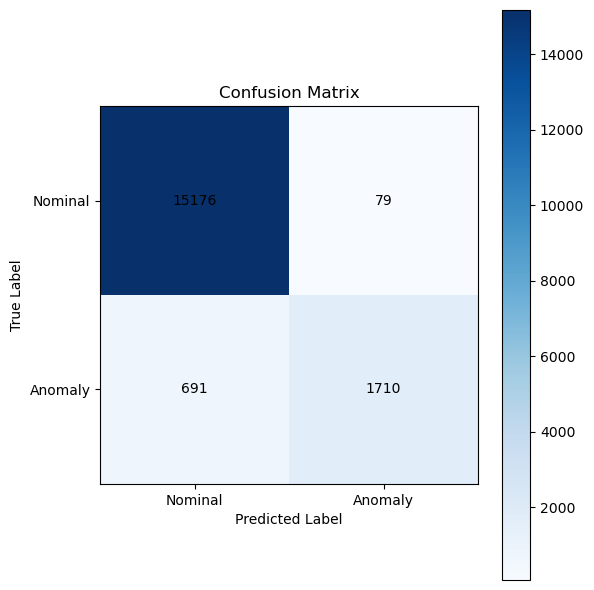

In [15]:
import pickle
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

# Load model from pickle file
with open("random_forest_model.pkl", "rb") as f:
    clf_rf = pickle.load(f)
print("Model loaded successfully")
# B3.2 Obtain predictions for the test set for RF classifier
preds = clf_rf.predict(X_test)
# B3.3 Compute and plot the confusion matrix for RF classifier


# confusion matrix
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm,cmap='Blues')
# labels
classes = ['Nominal', 'Anomaly']
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j,i,str(cm[i, j]),ha='center',va='center')

plt.colorbar(im)
plt.tight_layout()
plt.show()

# The confusion matrix shows that the Random Forest classifier correctly identifies most nominal telemetry windows, with a relatively small number of false alarms.

For the anomalous class, the model successfully detects a large number of anomalous windows (`True Positives = 1710`), although some anomalies are still missed (`False Negatives = 691`).

This illustrates a common trade-off in anomaly detection increasing anomaly sensitivity may also increase false alarms, while reducing false alarms can lead to missed anomalous events.

Overall, the results indicate that the model learns meaningful differences between nominal and anomalous telemetry behavior.

Ma trận nhầm lẫn cho thấy bộ phân loại Random Forest nhận diện chính xác phần lớn các cửa sổ telemetry bình thường, với số lượng cảnh báo sai tương đối nhỏ.

Đối với lớp bất thường, mô hình phát hiện thành công một số lượng lớn các cửa sổ bất thường (True Positives = 1710), mặc dù vẫn còn một số bất thường bị bỏ sót (False Negatives = 691).

Điều này minh họa một sự đánh đổi phổ biến trong bài toán phát hiện bất thường: tăng độ nhạy với bất thường có thể làm tăng số lượng cảnh báo sai, trong khi giảm cảnh báo sai lại có thể dẫn đến việc bỏ sót các sự kiện bất thường.

Nhìn chung, kết quả cho thấy mô hình đã học được những khác biệt có ý nghĩa giữa hành vi telemetry bình thường và bất thường.

### 3.1.2 Evaluation of the model performance: Performance metrics

After training the model, we evaluate its performance on the test set.

The `classification_report` summarizes several common classification metrics:
- `precision`: proportion of predicted anomalies that are truly anomalous,
- `recall`: proportion of true anomalies successfully detected,
- `f1-score`: harmonic mean between precision and recall,
- `support`: number of samples belonging to each class.

These metrics provide a first overview of how well the model distinguishes between nominal and anomalous telemetry windows.

classification_report tóm tắt một số chỉ số đánh giá phân loại phổ biến:

- precision (độ chính xác): tỉ lệ các cửa sổ được dự đoán là bất thường thực sự là bất thường
- recall (độ nhạy): tỉ lệ các bất thường thực sự được mô hình phát hiện thành công
- f1-score: trung bình điều hòa giữa precision và recall
- support: số lượng mẫu thuộc mỗi lớp

Các chỉ số này cung cấp cái nhìn tổng quan ban đầu về khả năng của mô hình trong việc phân biệt giữa các cửa sổ telemetry bình thường và bất thường.

In [16]:
# B3.4 Calculate and show performance metrics for RF classifier
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     15255
           1       0.96      0.71      0.82      2401

    accuracy                           0.96     17656
   macro avg       0.96      0.85      0.90     17656
weighted avg       0.96      0.96      0.95     17656



The classification metrics confirm the behavior observed in the confusion matrix.

The model achieves:
- High precision for both nominal and anomalous windows,
- High recall for the nominal class,
- Moderate recall for anomalous windows.

The anomaly recall (`0.71`) indicates that most anomalous windows are successfully detected, although some anomalous behaviors are still missed.

The high anomaly precision (`0.96`) suggests that when the model predicts an anomaly, it is usually correct, resulting in a relatively low false alarm rate.

Các chỉ số phân loại (classification metrics) xác nhận những quan sát từ ma trận nhầm lẫn.

Mô hình đạt được:

- Độ chính xác cao (precision) cho cả cửa sổ bình thường và bất thường,
- Độ nhạy cao (recall) cho lớp bình thường,
- Độ nhạy vừa phải (moderate recall) cho các cửa sổ bất thường.

Độ nhạy của bất thường (recall = 0.71) cho thấy hầu hết các cửa sổ bất thường đều được phát hiện thành công, mặc dù vẫn còn một số hành vi bất thường bị bỏ sót.

Độ chính xác của bất thường cao (precision = 0.96) cho thấy khi mô hình dự đoán một bất thường, dự đoán đó thường đúng, dẫn đến tỉ lệ cảnh báo sai tương đối thấp.